# 🫀 Heart Disease Prediction

##  Problem Statement
Heart disease is one of the leading causes of mortality worldwide. Early diagnosis and timely medical intervention can greatly improve patient outcomes and reduce healthcare costs. The goal of this project is to develop a machine learning model that predicts the presence of heart disease in a patient using various clinical features. Such predictive tools can support healthcare professionals in making data-driven decisions and prioritizing at-risk individuals for further diagnosis or treatment.

---

##  About the Dataset
The dataset used for this project is the **Heart Disease Dataset**, sourced from Kaggle. It is a compilation of medical records from four databases: **Cleveland, Hungary, Switzerland, and Long Beach V**, originally compiled in **1988**. Although the dataset contains **76 attributes**, most studies and applications use a subset of **14** key features relevant for predicting heart disease.

The target variable (`target`) is binary:
- `0` = No heart disease
- `1` = Presence of heart disease

---

##  Features

| Feature                         | Description                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| `age`                            | Age of the patient                                                         |
| `sex`                            | Gender (1 = male; 0 = female)                                              |
| `cp`                             | Chest pain type (4 values: typical angina, atypical angina, etc.)          |
| `trestbps`                       | Resting blood pressure (in mm Hg)                                          |
| `chol`                           | Serum cholesterol in mg/dl                                                 |
| `fbs`                            | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)                      |
| `restecg`                        | Resting electrocardiographic results (0, 1, 2)                             |
| `thalach`                        | Maximum heart rate achieved                                                |
| `exang`                          | Exercise-induced angina (1 = yes; 0 = no)                                  |
| `oldpeak`                        | ST depression induced by exercise relative to rest                         |
| `slope`                          | Slope of the peak exercise ST segment                                      |
| `ca`                             | Number of major vessels (0–3) colored by fluoroscopy                       |
| `thal`                           | Thalassemia (0 = normal; 1 = fixed defect; 2 = reversible defect)          |
| `target`                         | Heart disease presence (1 = yes; 0 = no)                                   |

---

##  Date Collected
The original data was compiled in **1988** and has since been widely used in medical and data science research.

---

##  Source
Dataset available on Kaggle:  
[https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)


In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data\heart_disease.csv')
# checking the first 5 rows
df.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(723)

In [8]:
1025 - 723

302

In [9]:
# dropping the duplicated values
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(302, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


## 🧹 Data Cleaning Observations

- The original dataset contained **1,025 entries** and **14 features**.
- Upon inspection, **723 duplicate rows** were found in the dataset.
- These duplicates were removed, resulting in a cleaned dataset with **302 unique entries**.
- All columns still have **non-null values**, and the data types remain unchanged.
- The dataset is now free from redundancy and ready for accurate exploratory analysis and modeling.


In [12]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# EDA

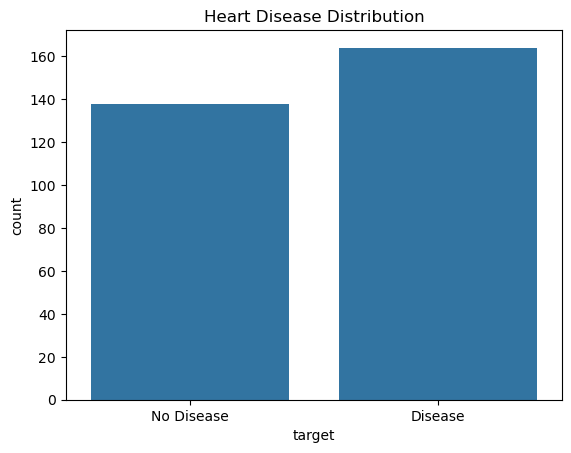

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

In [13]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.show()

df['target'].value_counts(normalize=True) * 100


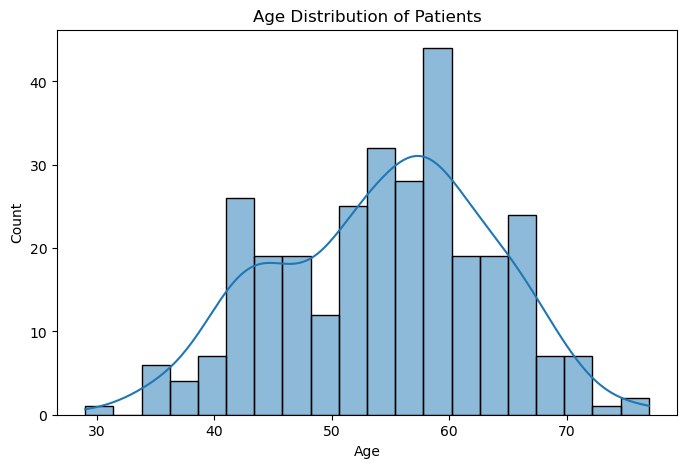

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


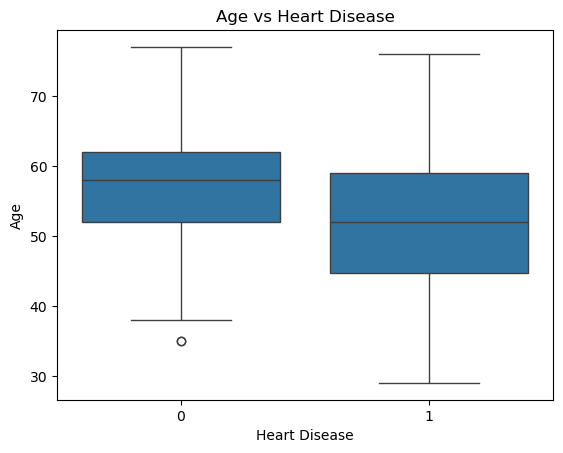

In [15]:
sns.boxplot(x='target', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age')
plt.show()


## 📈 Age vs. Heart Disease

- The average age of patients with heart disease is slightly **higher/lower** than those without.
- There are some **outliers** in both groups, especially among older patients.


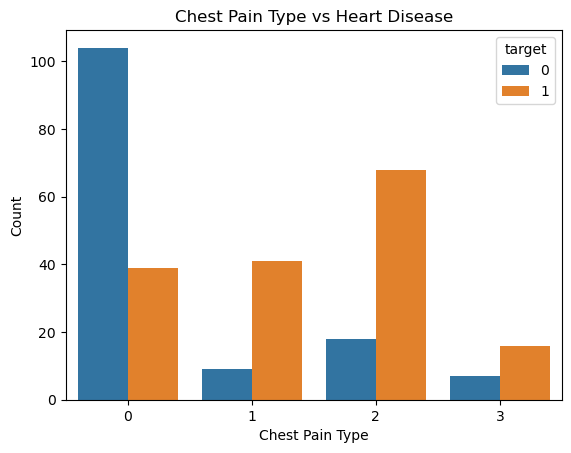

In [16]:
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()


## 💥 Chest Pain Type vs Heart Disease

- Patients with **chest pain type 1 or 2** are more likely to have heart disease.
- Chest pain type appears to be a **significant indicator**.


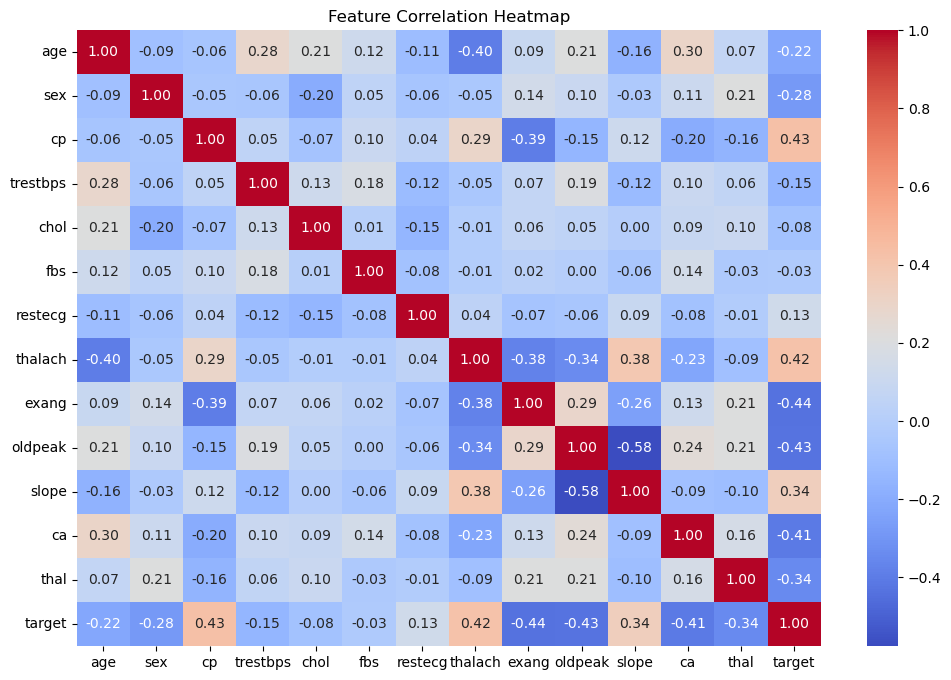

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()


## 🔗 Correlation Analysis

- The target variable shows **positive correlation** with `cp` and `thalach`, and **negative correlation** with `exang`, `oldpeak`, and `ca`.
- These features may be important for predictive modeling.


In [18]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [19]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

# Preprocessing

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


In [21]:
# Define categorical and numerical columns
categorical_cols = ['cp', 'thal', 'slope']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [22]:
# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scaling numerical columns
        ('cat', OneHotEncoder(drop='first'), categorical_cols)  # One-hot encoding categorical columns
    ])


In [23]:
# Apply the ColumnTransformer to the dataset
X = df.drop('target', axis=1)
y = df['target']

# Apply the transformation
X_processed = preprocessor.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)


In [24]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")


Shape of X_train: (241, 13)
Shape of X_test: (61, 13)


# Logistic Regression


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [26]:
# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=1000)

# Train the model on the training data
logreg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logreg.predict(X_test)


In [27]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8197
Confusion Matrix:
[[23  5]
 [ 6 27]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        28
           1       0.84      0.82      0.83        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



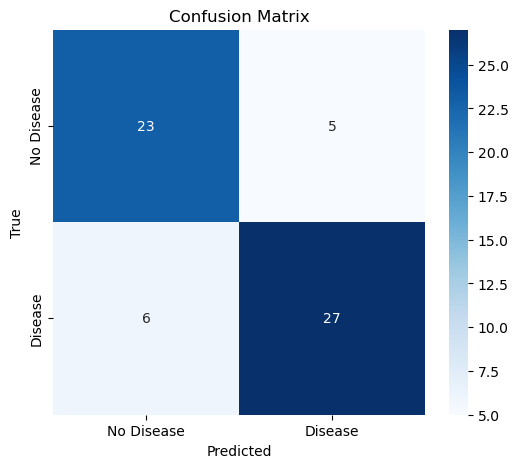

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix using seaborn heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier


In [30]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)


In [31]:
# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# Confusion matrix
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7869
Random Forest Confusion Matrix:
[[21  7]
 [ 6 27]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



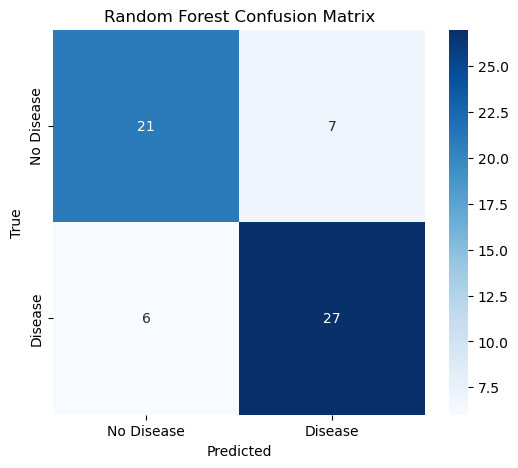

In [32]:
# Plot confusion matrix using seaborn heatmap
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [33]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best parameters from Grid Search
print("Best parameters:", grid_search.best_params_)

# Train the best model
best_logreg = grid_search.best_estimator_

# Evaluate the best model
y_pred_best = best_logreg.predict(X_test)
print(f"Accuracy (Tuned): {accuracy_score(y_test, y_pred_best):.4f}")


Best parameters: {'C': 10, 'solver': 'liblinear'}
Accuracy (Tuned): 0.7869


In [34]:
import pickle

# Save the model
with open('heart_disease_logreg_model.pkl', 'wb') as model_file:
    pickle.dump(best_logreg, model_file)
